# Rain Prediction using Gradient Boosting

This notebook implements a **Gradient Boosting Classifier** to predict whether it will rain tomorrow using a preprocessed and balanced WeatherAUS dataset.

The dataset has already undergone:
- Data cleaning
- Feature encoding
- Handling missing values
- Class imbalance correction (SMOTE)

This notebook focuses only on:
- Model training
- Evaluation
- Optimization

### Data Source
This dataset has been preprocessed and balanced using SMOTE in a separate notebook.
The balanced dataset is used here for model training to improve classification performance.

## Import Required Libraries

We import necessary libraries for:
- Data handling (Pandas, NumPy)
- Visualization (Matplotlib, Seaborn)
- Machine Learning (Scikit-learn)

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

## Load Balanced Dataset

The dataset used here has been preprocessed and balanced in a separate pipeline.
We verify its structure and target distribution.

In [7]:
df = pd.read_csv("weatherAUS_balanced.csv")

print("Dataset Shape:", df.shape)

print("\nTarget Distribution:")
print(df["RainTomorrow"].value_counts())
print(df["RainTomorrow"].value_counts(normalize=True))

Dataset Shape: (220632, 23)

Target Distribution:
RainTomorrow
0.0    110316
1.0    110316
Name: count, dtype: int64
RainTomorrow
0.0    0.5
1.0    0.5
Name: proportion, dtype: float64


## Data Inspection

We check:
- Column names
- Missing values
- Overall dataset structure

In [8]:
print("\nColumns:\n", df.columns)
print("\nMissing Values:\n", df.isna().sum().sum())


Columns:
 Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RainTomorrow'],
      dtype='object')

Missing Values:
 492455


## Feature Engineering (Optional)

If the dataset still contains a Date column, we extract useful temporal features:
- Year
- Month
- Day
- Day of Year

Then the original Date column is removed.

In [9]:
if "Date" in df.columns:
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df["Year"] = df["Date"].dt.year
    df["Month"] = df["Date"].dt.month
    df["Day"] = df["Date"].dt.day
    df["DayOfYear"] = df["Date"].dt.dayofyear
    df = df.drop(columns=["Date"])

## Feature and Target Separation

- Features (X): All input variables
- Target (y): RainTomorrow (binary classification)

In [10]:
X = df.drop("RainTomorrow", axis=1)
y = df["RainTomorrow"]

## Identify Numerical and Categorical Features

We separate features into:
- Numerical features
- Categorical features

In [11]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

print("Numeric Features:", len(numeric_features))
print("Categorical Features:", len(categorical_features))

Numeric Features: 17
Categorical Features: 4


## Preprocessing Pipeline

We define transformations:
- Numerical: median imputation + scaling
- Categorical: most frequent imputation + one-hot encoding

In [12]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

## Train-Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Gradient Boosting with Pipeline

The pipeline combines preprocessing and model training into a single workflow.

In [14]:
model_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(random_state=42))
])

model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm',
       'Temp9am', 'Temp3pm', 'RainToday'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm'], dtype='object'))])),
                ('model', GradientBoostingClassifier(random_state=42))])

## Base Model Evaluation

In [15]:
y_pred_base = model_pipeline.predict(X_test)
y_prob_base = model_pipeline.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, y_pred_base))
print(classification_report(y_test, y_pred_base))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_base))

[[17673  4391]
 [ 4896 17167]]
              precision    recall  f1-score   support

         0.0       0.78      0.80      0.79     22064
         1.0       0.80      0.78      0.79     22063

    accuracy                           0.79     44127
   macro avg       0.79      0.79      0.79     44127
weighted avg       0.79      0.79      0.79     44127

ROC-AUC: 0.8776610604703513


## Hyperparameter Tuning using GridSearchCV

In [16]:

param_grid = {
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.05, 0.1],
    'model__max_depth': [3, 4],
    'model__subsample': [0.8, 1.0]
}

grid = GridSearchCV(
    model_pipeline,
    param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

best_model = grid.best_estimator_

Best Parameters: {'model__learning_rate': 0.1, 'model__max_depth': 4, 'model__n_estimators': 200, 'model__subsample': 0.8}


## Final Model Evaluation

In [17]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

[[17977  4087]
 [ 4356 17707]]
              precision    recall  f1-score   support

         0.0       0.80      0.81      0.81     22064
         1.0       0.81      0.80      0.81     22063

    accuracy                           0.81     44127
   macro avg       0.81      0.81      0.81     44127
weighted avg       0.81      0.81      0.81     44127

ROC-AUC: 0.8952224153609561


## Confusion Matrix Visualization

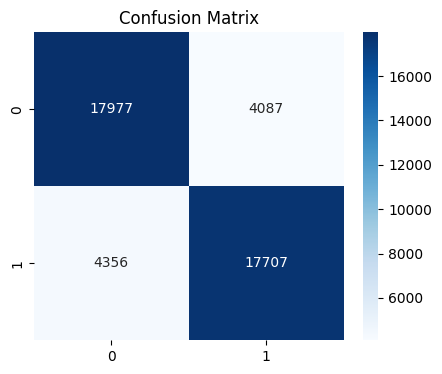

In [18]:
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

## ROC Curve

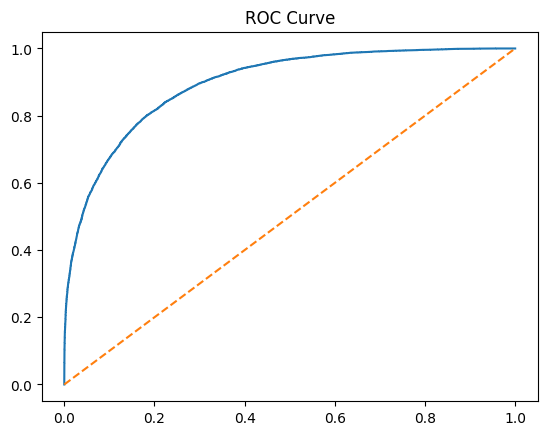

In [19]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')
plt.title("ROC Curve")
plt.show()

## Feature Importance

Feature importance is extracted from the trained model.

In [20]:
model = best_model.named_steps["model"]

importances = model.feature_importances_

print("Feature importance extracted (after encoding)")

Feature importance extracted (after encoding)


## Overfitting Analysis

In [22]:
train_score = best_model.score(X_train, y_train)
test_score = best_model.score(X_test, y_test)

print("Train:", train_score)
print("Test:", test_score)

Train: 0.8133310671085805
Test: 0.8086658961633467


## Conclusion

The Gradient Boosting model combined with a preprocessing pipeline provides:
- Accurate predictions
- Robust handling of categorical variables
- Reduced data leakage

Future improvements:
- Use advanced boosting techniques